# Consumer Behavioral Profiling
**Core Pattern:** Conditional Vectorization & Multi-Key Profiling

Distance and tip tiers via nested conditionals, card payments only.

In [1]:
import sys, os

try:
    import datapunk  # noqa: F401
except ImportError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

os.environ["DAFT_PROGRESS_BAR"] = "0"
import plotly.io as pio

pio.renderers.default = "svg"

from datapunk.reporter import DatapunkReporter

RAM_CAP = 1024  # in MB

reporter = DatapunkReporter(
    small_months=1,
    large_cap_mb=RAM_CAP,
    with_lookup=False,
)

  ⚙ unifying schema across 24 files (20 cols)…
     ✅ unified files cached.


Datapunk Environment
----------------------------------------------------
  OS:        Darwin 25.3.0
  CPU:       Apple M1 Pro (8 cores)
  RAM:       16.0 GB
  Python:    v3.14.6
  Small run: 1 month, uncapped, 10 iter + 1 warmup
  Large run: 24 months, cap = 1024 MB (physical RSS), 1 iter + 0 warmup
----------------------------------------------------


## Analytics Functions

In [2]:
# CARD payments only (payment_type = 1): tip_amount is not recorded for cash, which
# would otherwise show up as a huge fake "No Tip" bucket.
TAXI_COLS = ["payment_type", "trip_distance", "tip_amount"]
PARQUET_FILTERS = [[("payment_type", "==", 1)]]


def _duckdb_materialize(query, params, *, capped=False):
    import duckdb
    import uuid
    from datapunk.fingerprint import DuckDBTableResult

    con = duckdb.connect()
    if capped:
        con.execute(f"SET memory_limit='{int(RAM_CAP * 0.8)}MB'")

    table = f"datapunk_result_{uuid.uuid4().hex}"
    con.execute(f"CREATE TEMP TABLE {table} AS {query}", params)
    return DuckDBTableResult(con=con, table=table)


def conditional_profiling_pandas(file_path):
    import numpy as np
    import pandas as pd

    df = pd.concat(
        [
            pd.read_parquet(p, columns=TAXI_COLS, filters=PARQUET_FILTERS)
            for p in file_path
        ],
        ignore_index=True,
    )
    df = df[df["payment_type"] == 1].copy()
    df["distance_tier"] = np.select(
        [df["trip_distance"] <= 2.0, df["trip_distance"] <= 5.0],
        ["Short", "Medium"],
        default="Long",
    )
    df["tip_profile"] = np.select(
        [df["tip_amount"] == 0.0, df["tip_amount"] <= 5.0],
        ["No Tip", "Standard Tip"],
        default="High Tip",
    )
    result = (
        df.groupby(["distance_tier", "tip_profile"], sort=True)
        .size()
        .reset_index(name="total_trips")
        .copy()
    )
    return result, {"engine": pd.__name__, "version": pd.__version__}


def conditional_profiling_polars(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .filter(pl.col("payment_type") == 1)
        .select("trip_distance", "tip_amount")
        .with_columns(
            [
                pl.when(pl.col("trip_distance") <= 2.0)
                .then(pl.lit("Short"))
                .when(pl.col("trip_distance") <= 5.0)
                .then(pl.lit("Medium"))
                .otherwise(pl.lit("Long"))
                .alias("distance_tier"),
                pl.when(pl.col("tip_amount") == 0.0)
                .then(pl.lit("No Tip"))
                .when(pl.col("tip_amount") <= 5.0)
                .then(pl.lit("Standard Tip"))
                .otherwise(pl.lit("High Tip"))
                .alias("tip_profile"),
            ]
        )
        .group_by(["distance_tier", "tip_profile"])
        .agg(pl.len().alias("total_trips"))
    )
    result = lf.collect()
    return result, {"engine": pl.__name__, "version": pl.__version__}


def conditional_profiling_polars_streaming(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .filter(pl.col("payment_type") == 1)
        .select("trip_distance", "tip_amount")
        .with_columns(
            [
                pl.when(pl.col("trip_distance") <= 2.0)
                .then(pl.lit("Short"))
                .when(pl.col("trip_distance") <= 5.0)
                .then(pl.lit("Medium"))
                .otherwise(pl.lit("Long"))
                .alias("distance_tier"),
                pl.when(pl.col("tip_amount") == 0.0)
                .then(pl.lit("No Tip"))
                .when(pl.col("tip_amount") <= 5.0)
                .then(pl.lit("Standard Tip"))
                .otherwise(pl.lit("High Tip"))
                .alias("tip_profile"),
            ]
        )
        .group_by(["distance_tier", "tip_profile"])
        .agg(pl.len().alias("total_trips"))
    )
    result = lf.collect(engine="streaming")
    return result, {"engine": f"{pl.__name__}-streaming", "version": pl.__version__}


def conditional_profiling_duckdb(file_path):
    import duckdb

    query = """
        SELECT
            CASE WHEN trip_distance <= 2.0 THEN 'Short'
                 WHEN trip_distance <= 5.0 THEN 'Medium' ELSE 'Long' END AS distance_tier,
            CASE WHEN tip_amount = 0.0 THEN 'No Tip'
                 WHEN tip_amount <= 5.0 THEN 'Standard Tip' ELSE 'High Tip' END AS tip_profile,
            COUNT(*) AS total_trips
        FROM read_parquet($files)
        WHERE payment_type = 1
        GROUP BY 1, 2
    """
    result = _duckdb_materialize(query, {"files": list(map(str, file_path))})
    return result, {"engine": duckdb.__name__, "version": duckdb.__version__}


def conditional_profiling_duckdb_capped(file_path):
    import duckdb

    query = """
        SELECT
            CASE WHEN trip_distance <= 2.0 THEN 'Short'
                 WHEN trip_distance <= 5.0 THEN 'Medium' ELSE 'Long' END AS distance_tier,
            CASE WHEN tip_amount = 0.0 THEN 'No Tip'
                 WHEN tip_amount <= 5.0 THEN 'Standard Tip' ELSE 'High Tip' END AS tip_profile,
            COUNT(*) AS total_trips
        FROM read_parquet($files)
        WHERE payment_type = 1
        GROUP BY 1, 2
    """
    result = _duckdb_materialize(
        query, {"files": list(map(str, file_path))}, capped=True
    )
    return result, {
        "engine": f"{duckdb.__name__}-capped",
        "version": duckdb.__version__,
    }


def _distance_tier_partition(s):
    import numpy as np
    import pandas as pd

    return pd.Series(
        np.select([s <= 2.0, s <= 5.0], ["Short", "Medium"], default="Long"),
        index=s.index,
        dtype="object",
        name="distance_tier",
    )


def _tip_profile_partition(s):
    import numpy as np
    import pandas as pd

    return pd.Series(
        np.select([s == 0.0, s <= 5.0], ["No Tip", "Standard Tip"], default="High Tip"),
        index=s.index,
        dtype="object",
        name="tip_profile",
    )


def conditional_profiling_dask(file_path):
    import dask
    import dask.dataframe as dd

    df = dd.read_parquet(file_path, columns=TAXI_COLS, filters=PARQUET_FILTERS)
    df = df[df["payment_type"] == 1]
    df = df.assign(
        distance_tier=df["trip_distance"].map_partitions(
            _distance_tier_partition,
            meta=("distance_tier", "object"),
        ),
        tip_profile=df["tip_amount"].map_partitions(
            _tip_profile_partition,
            meta=("tip_profile", "object"),
        ),
    )
    result = df.groupby(["distance_tier", "tip_profile"]).size().reset_index().compute()
    result = result.rename(columns={0: "total_trips"})
    return result, {"engine": dask.__name__, "version": dask.__version__}


def conditional_profiling_daft(file_path):
    import daft

    df = daft.read_parquet(list(file_path)).select(
        "payment_type", "trip_distance", "tip_amount"
    )
    df = df.filter(df["payment_type"] == 1)
    df = df.with_column(
        "distance_tier",
        daft.sql_expr(
            "CASE WHEN trip_distance <= 2.0 THEN 'Short' WHEN trip_distance <= 5.0 THEN 'Medium' ELSE 'Long' END"
        ),
    )
    df = df.with_column(
        "tip_profile",
        daft.sql_expr(
            "CASE WHEN tip_amount = 0.0 THEN 'No Tip' WHEN tip_amount <= 5.0 THEN 'Standard Tip' ELSE 'High Tip' END"
        ),
    )
    result = (
        df.groupby(["distance_tier", "tip_profile"])
        .agg(daft.lit(1).count().alias("total_trips"))
        .collect()
    )
    return result, {"engine": daft.__name__, "version": daft.__version__}


ANALYTICS = [
    conditional_profiling_pandas,
    conditional_profiling_polars,
    conditional_profiling_polars_streaming,
    conditional_profiling_duckdb,
    conditional_profiling_duckdb_capped,
    conditional_profiling_dask,
    conditional_profiling_daft,
]

## Execution & Verification

In [3]:
reporter.run_all(ANALYTICS, target_cols=["distance_tier", "tip_profile", "total_trips"])
reporter.export_results(
    suite_id="04",
    title="Consumer Behavioral Profiling",
    core_pattern="Conditional Vectorization & Multi-Key Profiling",
    description="Distance and tip tiers via nested conditionals, card payments only.",
)


▶ SMALL run (1 month, cap=none)


    pandas v3.0.3              877 ms  peak 859 MB


    polars v1.41.2              56 ms  peak 418 MB


    polars-streaming v1.41.2      35 ms  peak 306 MB


    duckdb v1.5.4               55 ms  peak 135 MB


...

    polars-streaming v1.41.2     657 ms  peak 714 MB


    duckdb v1.5.4              944 ms  peak 189 MB


    duckdb-capped v1.5.4       829 ms  peak 190 MB


    dask v2026.6.0                OOM  peak 1064 MB


    daft v0.7.15              2073 ms  peak 891 MB
    → consistency: ✅ 4 engine(s) agree (9 rows)
📊 exported suite [04] → docs/benchmark_results.json


## Analysis

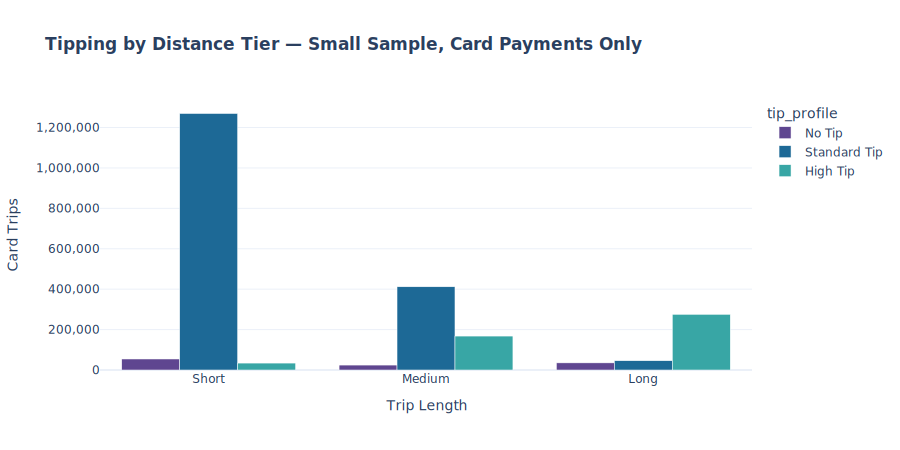

In [4]:
import plotly.express as px

# Visualization is intentionally standardized through pandas on the small run.
reporter.set_analysis_fn(conditional_profiling_pandas, mode="small")
df = reporter.get_analysis_df(["distance_tier", "tip_profile", "total_trips"])
fig = px.bar(
    df,
    x="distance_tier",
    y="total_trips",
    color="tip_profile",
    barmode="group",
    category_orders={
        "distance_tier": ["Short", "Medium", "Long"],
        "tip_profile": ["No Tip", "Standard Tip", "High Tip"],
    },
    title="<b>Tipping by Distance Tier — Small Sample, Card Payments Only</b>",
    labels={"distance_tier": "Trip Length", "total_trips": "Card Trips"},
    color_discrete_sequence=px.colors.qualitative.Prism,
)
fig.update_layout(template="plotly_white", yaxis_tickformat=",", width=900, height=450)
fig.show()

## Performance Comparison

In [5]:
reporter.show_scorecard("Conditional Vectorization Performance")

#### Conditional Vectorization Performance — Single Month · Uncapped

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | 0.8769s | 1.0×       | 859 MB     | —        |
| daft v0.7.15             | 0.0996s | 8.8×       | 236 MB     | —        |
| dask v2026.6.0           | 0.6065s | 1.4×       | 902 MB     | —        |
| duckdb v1.5.4            | 0.0553s | 15.9×      | 135 MB     | —        |
| duckdb-capped v1.5.4     | 0.0561s | 15.6×      | 137 MB     | —        |
| polars v1.41.2           | 0.0558s | 15.7×      | 418 MB     | —        |
| polars-streaming v1.41.2 | 0.0345s | **25.4×**  | 306 MB     | —        |

*✅ 7 engine(s) agree (9 rows)*

#### Conditional Vectorization Performance — Full Window · 1024 MB Cap

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | **OOM** | —          | ≥1045 MB   | ≥1.02    |
| daft v0.7.15             | 2.0729s | 1.0×       | 891 MB     | 0.87     |
| dask v2026.6.0           | **OOM** | —          | ≥1064 MB   | ≥1.04    |
| duckdb v1.5.4            | 0.9436s | 2.2×       | 189 MB     | 0.18     |
| duckdb-capped v1.5.4     | 0.8285s | 2.5×       | 190 MB     | 0.19     |
| polars v1.41.2           | **OOM** | —          | ≥1082 MB   | ≥1.06    |
| polars-streaming v1.41.2 | 0.6569s | **3.2×**   | 714 MB     | 0.70     |

*✅ 4 engine(s) agree (9 rows)*